# Evaluation of Experiments

This notebook contains the evaluation of 6 different experiments. These include

[1] Baseline experiments of well-known AL strategies \
[2] Ablation Study concerning the Oracle Type and the number of batches that are selected per cycle. \
[3] Ablation Study of the query size for best performer of experiment [2] \
[4] Ablation Study of the Performance Estimation for best performer of experiment [2] \
[5] Ablation Study of the retraining process for best performer of experiment [2] \
[6] Investigation of reducing selection strategies to top-k from experiment [2] \

Each Experiment will subsequently be introduced and results will be plottet.

In [2]:
# Some imports and general information

import mlflow
import numpy as np
import pylab as plt
from collections import defaultdict

# Command to sync the database
# rsync -avz cluster.ies:/mnt/stud/work/phahn/repositories/dal-toolbox/perf_dal.db /home/phahn/repositories/dal-toolbox/publications/perf_dal/evaluation/perf_dal.db

# Datasets
datasets = {
    'cifar10': {'bs':10, 'n':'CIFAR10'}, 
    'stl10':{'bs':10, 'n':'STL10'}, 
    'snacks':{'bs':20, 'n':'SNACKS'}, 
    'flowers102':{'bs':25, 'n':'Flowers102'}, 
    'dtd':{'bs':50, 'n':'DTD'}, 
    'food101':{'bs':100, 'n':'Food101'}, 
    'cifar100':{'bs':100, 'n':'CIFAR100'},
    'tiny_imagenet':{'bs':200, 'n': 'TinyImageNet'},
    'imagenet':{'bs':1000, 'n':'ImageNet'}
    }

# Query Strategies
query_strategies = {
    'alfamix':{'n':'AlfaMix', 'c':'red'},
    'badge':{'n':'BADGE', 'c':'blue'},
    'bait':{'n':'BAIT', 'c':'green'},
    'coreset':{'n':'CoreSet', 'c':'purple'},
    'dropquery':{'n':'DropQuery', 'c':'orange'},
    'margin':{'n':'Margin', 'c':'cyan'},
    'random':{'n':'Random', 'c':'black'},
    'typiclust':{'n':'Typiclust', 'c':'pink'}
}

# Load in all results
all_acc_curves_strategies = {}
all_pick_choices = {}
query_times = {}

# Mlflow args
uri = 'sqlite:///perf_dal.db'
client = mlflow.tracking.MlflowClient(tracking_uri=uri)

## Experiment 1 - Baselines

The first experiment contains the runs including well-known DAL-strategies on a variety of different Datasets. These include:

Datasets = [CIFAR10, CIFAR100, STL10, Snacks, DTD, Food101, Flowers102, TinyImageNet, ImageNet]

DAL Query Strategiges = [AlfaMix, BADGE, BAIT, CoreSet, DropQuery, Margin, Random, Typiclust]

In [3]:
experiment_name = 'experiment_1'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 9 * 10 * 8)) # n_dsets * n_seeds * n_query_strategies

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])

##################################### experiment_1 #####################################
Found 199 experiments for experiment_1 with expected 720 experiments.


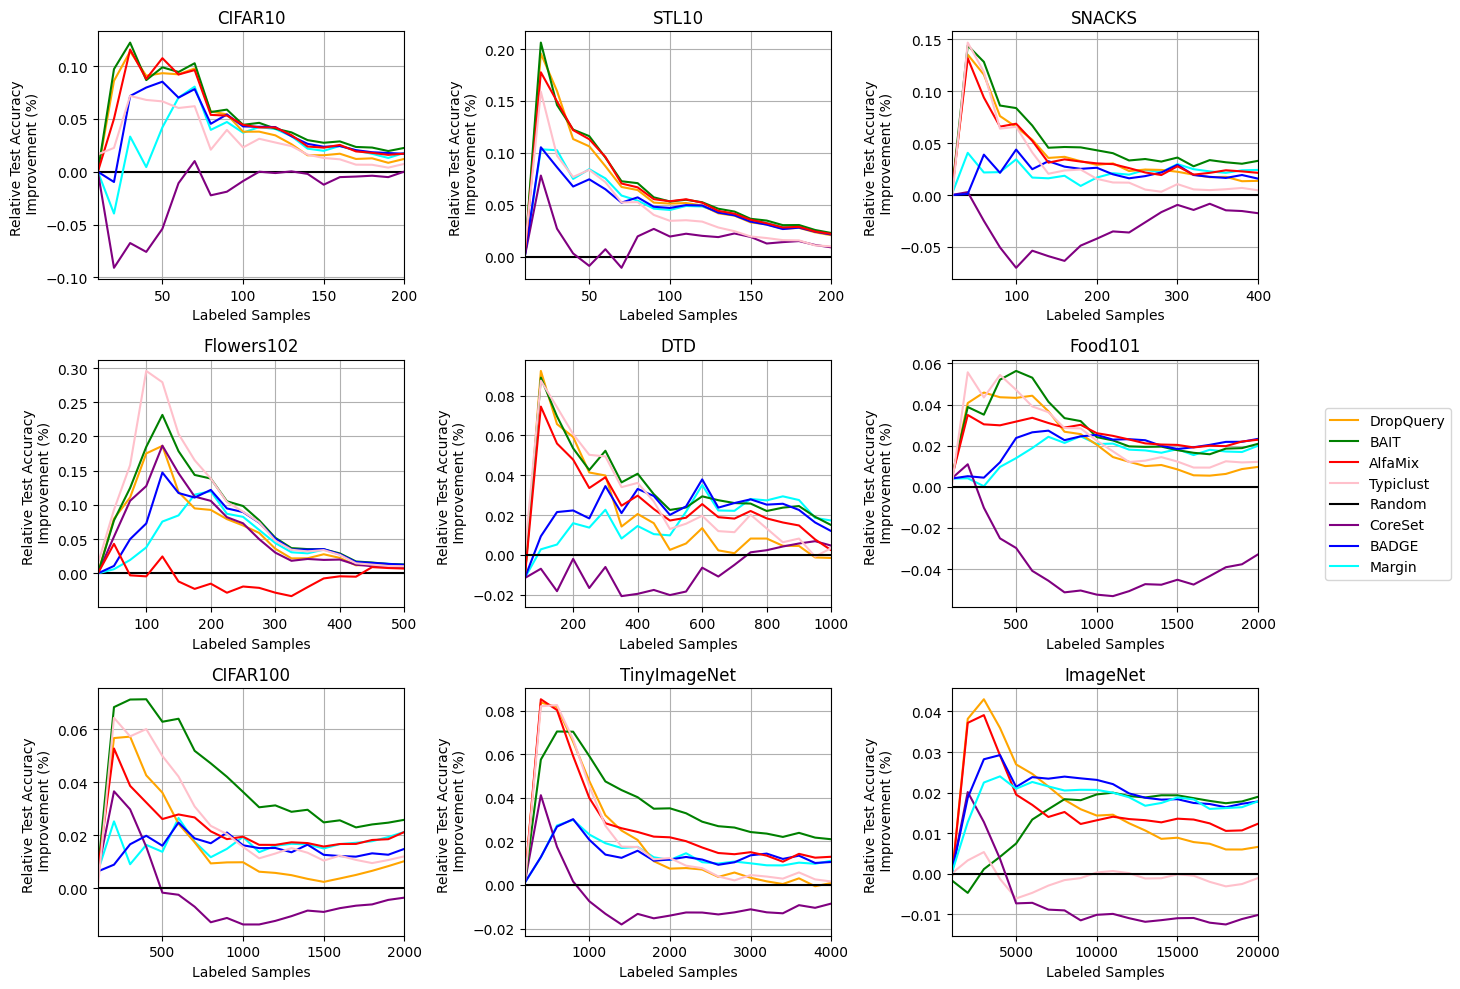

In [10]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(13, 10), tight_layout=True)

for i, dset in enumerate(datasets):
    plt.axes(ax[i//3][i%3])
    n_labeled_samples = [j*datasets[dset]['bs'] + datasets[dset]['bs'] for j in range(21)]
    for qs in all_acc_curves_strategies[dset]:
        plt.plot(n_labeled_samples, np.mean(all_acc_curves_strategies[dset][qs], axis=0) - np.mean(all_acc_curves_strategies[dset]['random'], axis=0), c=query_strategies[qs]['c'], label=query_strategies[qs]['n'])
    plt.xlabel('Labeled Samples')
    plt.ylabel('Relative Test Accuracy \n Improvement (%)')
    plt.grid(True)
    plt.title(datasets[dset]['n'])
    plt.xlim(datasets[dset]['bs'], 20*datasets[dset]['bs'])

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(loc="right", bbox_to_anchor=[1.125, .5], handles=handles, labels=labels)
plt.show()

## Experiment 2 - Oracle Variations and Number of Batches Ablation

The second experiment investigates different variants of the oracle strategy and additionally tests them for different number of batches per cycle to investigate.

Oracle_Variants = [Naive, Lazy, Intelligent but Lazy]

Batch_Sizes = [11, 55, 110]

In [ ]:
experiment_name = 'experiment_2'
print('#####################################', experiment_name, '#####################################')
experiment_id = client.get_experiment_by_name(experiment_name).experiment_id
runs_strategies = client.search_runs(experiment_ids=experiment_id)
print('Found {} experiments for {} with expected {} experiments.'.format(len(runs_strategies), experiment_name, 2 * 10 * 3 * 3)) # n_dsets * n_seeds * n_oracles * n_batches

for run in runs_strategies:
    key = run.data.params['al.strategy']
    dataset = run.data.params['dataset_name']
    accs = [m.value for m in client.get_metric_history(run.info.run_id, 'accuracy')]
    qts = [m.value for m in client.get_metric_history(run.info.run_id, 'query_time')]

    if len(accs) == 21:
        if dataset not in all_acc_curves_strategies:
            all_acc_curves_strategies[dataset] = defaultdict(list)
        all_acc_curves_strategies[dataset][key].append(accs)
        if dataset not in query_times:
            query_times[dataset] = defaultdict(list)
        query_times[dataset][key].append(qts)
    else:
        print('Issue with', key, dataset, 'Seed_'+run.data.params['random_seed'])